# 🧠 The Mind of a Model
# Day 7: Hyperparameter Tuning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
url = 'https://raw.githubusercontent.com/Aeshwa-Kachhadiya/The-mind-of-a-model/main/dataset/linkedin_post_performance.xlsx'

df = pd.read_excel(url)
print('✅ Dataset loaded!')
print(f'Shape: {df.shape}')

✅ Dataset loaded!
Shape: (300, 20)


In [ ]:
binary_cols = ['has_image', 'has_video', 'has_carousel',
               'has_hashtags', 'has_question', 'has_emoji',
               'is_weekend']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['went_viral'] = df['went_viral'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
df['topic_category'] = le.fit_transform(df['topic_category'])
df['posting_day'] = le.fit_transform(df['posting_day'])

numerical_cols = ['word_count', 'account_followers',
                  'account_age_months', 'posting_frequency',
                  'likes_first_hour', 'comments_first_hour',
                  'shares_first_hour', 'impressions_first_hour']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('✅ Data prepared!')

✅ Data prepared!


/tmp/ipykernel_17835/3617530617.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
X = df.drop(columns=['went_viral'])
y = df['went_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Testing set: {X_test.shape[0]} rows')

Training set: 240 rows
Testing set: 60 rows


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train with default settings
default_model = RandomForestClassifier(random_state=42)
default_model.fit(X_train, y_train)

default_acc = accuracy_score(y_test,
                             default_model.predict(X_test))

print('BEFORE TUNING:')
print(f'Default settings accuracy: {default_acc:.2%}')
print()
print('Default hyperparameters:')
print(f'n_estimators : 100')
print(f'max_depth    : None')
print(f'min_samples_split : 2')

BEFORE TUNING:
Default settings accuracy: 85.00%

Default hyperparameters:
n_estimators : 100
max_depth    : None
min_samples_split : 2


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

print('GRID SEARCH:')
print(f'Total combinations to try: {3 * 4 * 3}')
print('Trying every single combination...')
print()

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('✅ Grid Search complete!')
print()
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV score: {grid_search.best_score_:.2%}')

GRID SEARCH:
Total combinations to try: 36
Trying every single combination...

✅ Grid Search complete!

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 93.75%


In [ ]:
grid_acc = accuracy_score(y_test,
                          grid_search.best_estimator_.predict(X_test))

print('GRID SEARCH RESULT:')
print()
print(f'Before tuning : {default_acc:.2%}')
print(f'After tuning  : {grid_acc:.2%}')
print()
print(f'Improvement   : {(grid_acc - default_acc):.2%}')

GRID SEARCH RESULT:

Before tuning : 85.00%
After tuning  : 90.00%

Improvement   : 5.00%


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution
param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4]
}

print('RANDOM SEARCH:')
print('Trying 20 random combinations...')
print()

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print('✅ Random Search complete!')
print()
print(f'Best parameters: {random_search.best_params_}')
print(f'Best CV score: {random_search.best_score_:.2%}')

RANDOM SEARCH:
Trying 20 random combinations...

✅ Random Search complete!

Best parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Best CV score: 93.75%


In [ ]:
random_acc = accuracy_score(y_test,
                            random_search.best_estimator_.predict(X_test))

print('RANDOM SEARCH RESULT:')
print()
print(f'Before tuning  : {default_acc:.2%}')
print(f'Grid Search    : {grid_acc:.2%}')
print(f'Random Search  : {random_acc:.2%}')

RANDOM SEARCH RESULT:

Before tuning  : 85.00%
Grid Search    : 90.00%
Random Search  : 86.67%


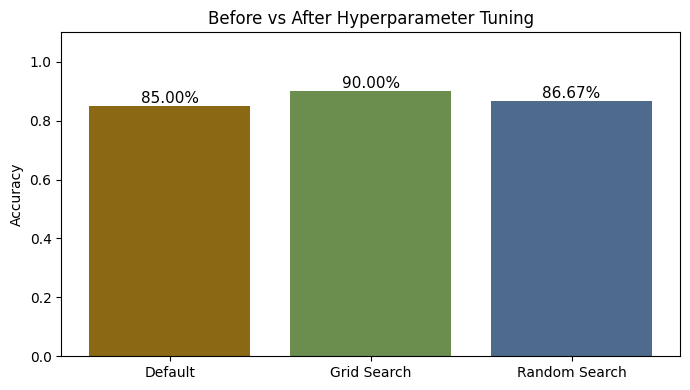

In [ ]:
labels = ['Default', 'Grid Search', 'Random Search']
scores = [default_acc, grid_acc, random_acc]
colors = ['#8B6914', '#6B8E4E', '#4E6B8E']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, scores, color=colors)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.2%}',
             ha='center', fontsize=11)

plt.title('Before vs After Hyperparameter Tuning')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()